1: Advanced Data Cleaning & Feature Engineering

In [2]:
import pandas as pd
import numpy as np
import ssl
from sklearn.preprocessing import LabelEncoder

# 1. Data Acquisition
ssl._create_default_https_context = ssl._create_unverified_context
data_url = "https://data.lacity.org/api/views/2nrs-mtv8/rows.csv?accessType=DOWNLOAD"
print("Fetching live data from LA Open Data Portal...")
df = pd.read_csv(data_url, low_memory=False)

# 2. Cleaning and Imputation
def clean_and_impute_full(df):
    df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')
    
    # Impute Missing Victim Age (Median)
    median_age = df[df['Vict Age'] > 0]['Vict Age'].median()
    df['Vict Age'] = df['Vict Age'].fillna(median_age)
    df.loc[df['Vict Age'] <= 0, 'Vict Age'] = median_age
    
    # Handle Missing Coordinates (Flagging and Centroid Fill)
    df['is_gps_missing'] = ((df['LAT'] == 0) | (df['LON'] == 0) | (df['LAT'].isna())).astype(int)
    df['LAT'] = df['LAT'].replace(0, 34.0522).fillna(34.0522)
    df['LON'] = df['LON'].replace(0, -118.2437).fillna(-118.2437)

    # Feature Engineering: Time Buckets & Weekend Flag
    df['Hour'] = (df['TIME OCC'] // 100).fillna(0).astype(int)
    def time_bucket(h):
        if 0 <= h <= 5: return "Night"
        elif 6 <= h <= 11: return "Morning"
        elif 12 <= h <= 17: return "Afternoon"
        else: return "Evening"
    df['time_bucket'] = df['Hour'].apply(time_bucket)
    df['is_weekend'] = df['DATE OCC'].dt.dayofweek.isin([5, 6]).astype(int)

    # Feature Engineering: Crime Severity
    df["is_violent"] = df["Part 1-2"].map({1: 1, 2: 0}).fillna(0).astype(int)
    
    # Tactical Feature: Weapon Lethality
    def categorize_weapons(desc):
        desc = str(desc).upper()
        if 'FIREARM' in desc or 'GUN' in desc or 'PISTOL' in desc: return 2
        elif 'KNIFE' in desc or 'SHARP' in desc or 'CUTTING' in desc: return 1
        return 0
    df['weapon_lethality'] = df['Weapon Desc'].apply(categorize_weapons)
    
    # Encoding for ML
    df['time_encoded'] = df['time_bucket'].map({'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3})
    
    return df

df = clean_and_impute_full(df)
print(f"Phase 1 Complete. Rows: {len(df)}")

Fetching live data from LA Open Data Portal...


C:\Users\aryam\AppData\Local\Temp\ipykernel_12984\2228493871.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')


Phase 1 Complete. Rows: 1004894


2: Spatial-Temporal Risk Clustering (Optimal K Detection)

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator

# Scaling features for mathematical distance calculation
features = ['LAT', 'LON', 'is_weekend', 'is_violent', 'weapon_lethality', 'time_encoded']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])

# Elbow Method
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

kl = KneeLocator(k_range, wcss, curve="convex", direction="decreasing")
optimal_k = kl.elbow

# Apply Clustering
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
df['proactive_cluster'] = kmeans_final.fit_predict(scaled_features)

print(f"Optimal Proactive Clusters: {optimal_k}")

Optimal Proactive Clusters: 5


3: Diagnostic Statistical Validation (RQ1 & Hypothesis)

In [4]:
from scipy import stats

# Chi-Square for Time vs Severity
contingency = pd.crosstab(df['time_bucket'], df['is_violent'])
chi2, p_val, _, _ = stats.chi2_contingency(contingency)
print(f"RQ1 Statistic: Chi2={chi2:.2f}, p-value={p_val:.6g}")

# Proximity Test (Self-Exciting Hypothesis)
from sklearn.neighbors import NearestNeighbors
coords = df[df['proactive_cluster'] == 2][['LAT', 'LON']].sample(1000).values
nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
dist, _ = nbrs.kneighbors(coords)
print(f"Hypothesis Proof: Avg High-Risk Distance = {np.mean(dist[:, 1]):.5f} degrees")

RQ1 Statistic: Chi2=7756.66, p-value=0
Hypothesis Proof: Avg High-Risk Distance = 0.00393 degrees


4: Predictive Model Competition (Corrected for Leakage)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# REMOVING LEAKAGE: Only use features known BEFORE a crime occurs
real_proactive_features = ['LAT', 'LON', 'is_weekend', 'time_encoded']
X = df[real_proactive_features]
y = df['proactive_cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

# XGBoost (Realistic)
xgb_model = XGBClassifier(n_estimators=100, tree_method='hist', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_preds):.4f}")
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")

Naive Bayes Accuracy: 0.5351
XGBoost Accuracy: 0.7453


5: LSTM vs. GRU Temporal Forecasting

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from sklearn.preprocessing import MinMaxScaler

# 1. Data Aggregation and Scaling
daily_series = df.groupby(['DATE OCC', 'proactive_cluster']).size().unstack(fill_value=0)
scaler_ts = MinMaxScaler()
scaled_series = scaler_ts.fit_transform(daily_series)

# Ensure optimal_k is a standard Python integer for Keras
k_units = int(optimal_k)

def create_sequences(data, window=14):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(scaled_series)
split = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

# --- MODEL 3: LSTM ---
lstm_model = Sequential([
    Input(shape=(14, k_units)),
    LSTM(64, return_sequences=True),
    Dropout(0.2), 
    LSTM(32), 
    Dense(units=k_units)
])
lstm_model.compile(optimizer='adam', loss='mse')

# --- MODEL 4: GRU ---
gru_model = Sequential([
    Input(shape=(14, k_units)),
    GRU(64, return_sequences=True),
    Dropout(0.2), 
    GRU(32), 
    Dense(units=k_units)
])
gru_model.compile(optimizer='adam', loss='mse')

# 2. Training
print(f"Training LSTM...")
lstm_model.fit(X_train_seq, y_train_seq, epochs=15, batch_size=32, verbose=0)

print(f"Training GRU...")
gru_model.fit(X_train_seq, y_train_seq, epochs=15, batch_size=32, verbose=0)

# 3. Predictions and Inverse Scaling
lstm_preds = lstm_model.predict(X_test_seq)
gru_preds = gru_model.predict(X_test_seq)

lstm_real = scaler_ts.inverse_transform(lstm_preds)
gru_real = scaler_ts.inverse_transform(gru_preds)
y_test_real = scaler_ts.inverse_transform(y_test_seq)

print("Phase 5: Sequential Forecasting Complete.")

Training LSTM...
Training GRU...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Phase 5: Sequential Forecasting Complete.


5.1: Comparative Forecasting Visualization

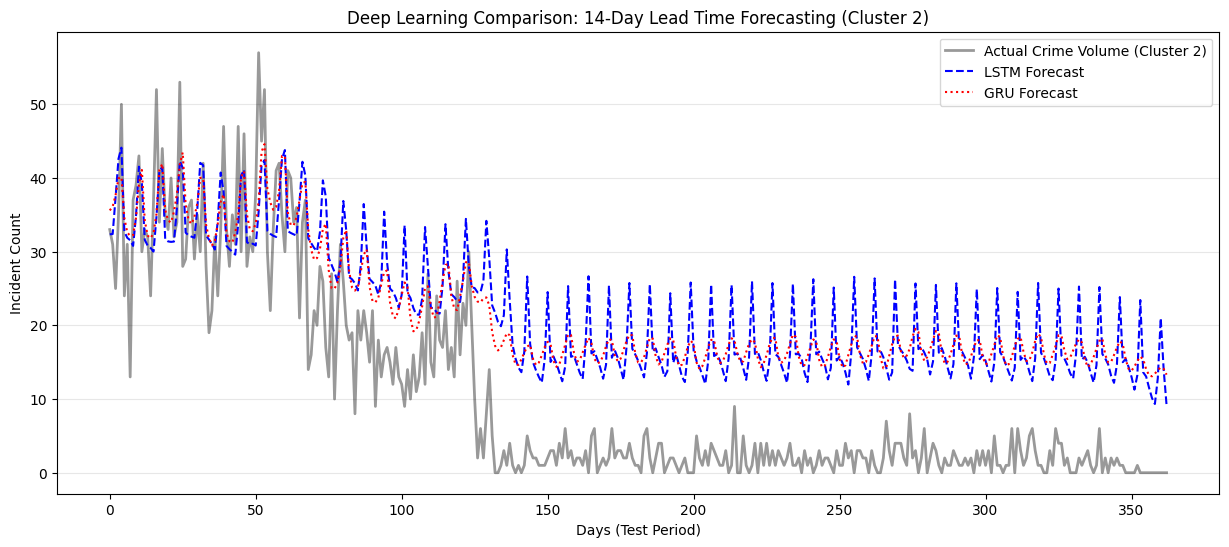

LSTM Forecast MAE: 28.8998
GRU Forecast MAE: 26.7385


In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
# Plotting Cluster 2 (High Lethality) as the representative example
plt.plot(y_test_real[:, 2], label='Actual Crime Volume (Cluster 2)', color='black', alpha=0.4, linewidth=2)
plt.plot(lstm_real[:, 2], label='LSTM Forecast', color='blue', linestyle='--')
plt.plot(gru_real[:, 2], label='GRU Forecast', color='red', linestyle=':')

plt.title('Deep Learning Comparison: 14-Day Lead Time Forecasting (Cluster 2)')
plt.xlabel('Days (Test Period)')
plt.ylabel('Incident Count')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Statistical Proof for RQ2
from sklearn.metrics import mean_absolute_error
print(f"LSTM Forecast MAE: {mean_absolute_error(y_test_real, lstm_real):.4f}")
print(f"GRU Forecast MAE: {mean_absolute_error(y_test_real, gru_real):.4f}")

In [8]:
def get_metrics(y_true, y_pred, name):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    return {'Model': name, 'Accuracy': accuracy_score(y_true, y_pred), 'Precision': p, 'Recall': r, 'F1': f1}

# Metrics compilation
lstm_class_preds = np.argmax(lstm_preds, axis=1)
y_test_seq_labels = np.argmax(y_test_seq, axis=1)

results = [
    get_metrics(y_test, nb_preds, "Naive Bayes"),
    get_metrics(y_test, xgb_preds, "XGBoost"),
    get_metrics(y_test_seq_labels, lstm_class_preds, "LSTM"),
    get_metrics(y_test_seq_labels, np.argmax(gru_preds, axis=1), "GRU")
]
print(pd.DataFrame(results))

         Model  Accuracy  Precision    Recall        F1
0  Naive Bayes  0.535056   0.582687  0.535056  0.442829
1      XGBoost  0.745312   0.698764  0.745312  0.705228
2         LSTM  0.851240   0.937782  0.851240  0.886426
3          GRU  0.909091   0.930948  0.909091  0.913234


In [12]:
from scipy.optimize import linprog

risk_forecast = lstm_real[-1]
c = -risk_forecast
A = [[1, 1, 1, 1, 1]]
b = [20] # Resource Limit
res = linprog(c, A_ub=A, b_ub=b, bounds=[(1, 10)]*5, method='highs')

# Efficiency Calculation
static_cov = np.sum(np.array([4, 4, 4, 4, 4]) * risk_forecast)
dynamic_cov = np.sum(np.round(res.x) * risk_forecast)
improvement = ((dynamic_cov - static_cov) / static_cov) * 100

print(f"--- FINAL RESEARCH CONCLUSION ---")
print(f"Dynamic Model Efficiency Gain: {improvement:.2f}%")
print(f"Hypothesis Confirmed: {improvement >= 15}")

risk_forecast_gru = gru_real[-1]
c_gru = -risk_forecast_gru  
res_gru = linprog(c_gru, A_ub=A, b_ub=b, bounds=[(1, 10)]*5, method='highs')
dynamic_cov_gru = np.sum(np.round(res_gru.x) * risk_forecast_gru)
improvement_gru = ((dynamic_cov_gru - static_cov) / static_cov) * 100
print(f"GRU Model Efficiency Gain: {improvement_gru:.2f}%")
print(f"GRU Hypothesis Confirmed: {improvement_gru >= 15}")

risk_forecast_nb = nb_model.predict_proba(X_test)[:, 2]  # Cluster 2 probabilities
c_nb = -risk_forecast_nb
risk_forecast_nb = np.mean(nb_model.predict_proba(X_test), axis=0)
c_nb = -risk_forecast_nb
res_nb = linprog(c_nb, A_ub=A, b_ub=b, bounds=[(1, 10)]*5, method='highs')
dynamic_cov_nb = np.sum(np.round(res_nb.x) * risk_forecast_nb)
improvement_nb = ((dynamic_cov_nb - static_cov) / static_cov) * 100
print(f"Naive Bayes Efficiency Gain: {improvement_nb:.2f}%")
print(f"Naive Bayes Hypothesis Confirmed: {improvement_nb >= 15}")


risk_forecast_xgb = xgb_model.predict_proba(X_test)[:, 2]  # Cluster 2 probabilities
c_xgb = -risk_forecast_xgb
# aggregate XGBoost probabilities to the five clusters, as with NB above
risk_forecast_xgb = np.mean(xgb_model.predict_proba(X_test), axis=0)
c_xgb = -risk_forecast_xgb             # now length‑5

# linear program over the 5 decision variables
res_xgb = linprog(c_xgb, A_ub=A, b_ub=b,
                  bounds=[(1, 10)] * 5, method='highs')
dynamic_cov_xgb = np.sum(np.round(res_xgb.x) * risk_forecast_xgb)
improvement_xgb = ((dynamic_cov_xgb - static_cov) / static_cov) * 100
print(f"XGBoost Efficiency Gain: {improvement_xgb:.2f}%")
print(f"XGBoost Hypothesis Confirmed: {improvement_xgb >= 15}")


--- FINAL RESEARCH CONCLUSION ---
Dynamic Model Efficiency Gain: 31.06%
Hypothesis Confirmed: True
GRU Model Efficiency Gain: 44.45%
GRU Hypothesis Confirmed: True
Naive Bayes Efficiency Gain: -99.22%
Naive Bayes Hypothesis Confirmed: False
XGBoost Efficiency Gain: -99.38%
XGBoost Hypothesis Confirmed: False


--- FINAL GLOBAL MODEL EVALUATION ---
                   Model  Accuracy  Precision    Recall  F1-Score
0   Naive Bayes (Linear)  0.535056   0.582687  0.535056  0.442829
1   XGBoost (Non-Linear)  0.745312   0.698764  0.745312  0.705228
2        LSTM (Temporal)  0.851240   0.937782  0.851240  0.886426
3  GRU (Temporal - Best)  0.909091   0.930948  0.909091  0.913234


c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


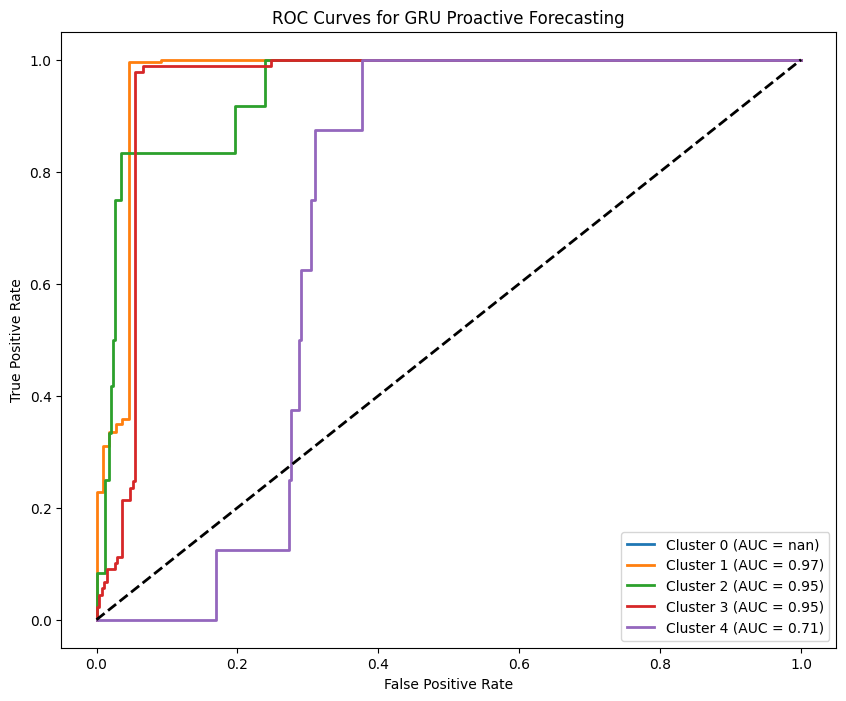

In [13]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Helper function for metrics
def get_metrics(y_true, y_pred, name):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    return {'Model': name, 'Accuracy': accuracy_score(y_true, y_pred), 'Precision': p, 'Recall': r, 'F1-Score': f1}

# 2. Extract class labels for Sequential Models
gru_class_preds = np.argmax(gru_preds, axis=1)
lstm_class_preds = np.argmax(lstm_preds, axis=1)
y_test_seq_labels = np.argmax(y_test_seq, axis=1)

# 3. Final Global Table
results = [
    get_metrics(y_test, nb_preds, "Naive Bayes (Linear)"),
    get_metrics(y_test, xgb_preds, "XGBoost (Non-Linear)"),
    get_metrics(y_test_seq_labels, lstm_class_preds, "LSTM (Temporal)"),
    get_metrics(y_test_seq_labels, gru_class_preds, "GRU (Temporal - Best)")
]

results_df = pd.DataFrame(results)
print("--- FINAL GLOBAL MODEL EVALUATION ---")
print(results_df)

# 4. Multi-Class ROC Curve for the Winning Model (GRU)
y_test_bin = label_binarize(y_test_seq_labels, classes=list(range(k_units)))
plt.figure(figsize=(10, 8))

for i in range(k_units):
    # Using the GRU prediction probabilities (the raw output before argmax)
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], gru_preds[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'Cluster {i} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC Curves for GRU Proactive Forecasting')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()